In [1]:
import json
import os
import pandas as pd
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

def parse_pages(path: str = './pages/') -> pd.DataFrame:
    books_list = os.listdir(path)
    df_rows = []

    for book in tqdm(books_list):
        with open(path + book, 'r', encoding='utf-8') as f:
            for line in f:
                book_dict = json.loads(line)
                if 'error' not in book_dict:
                    df_rows.append(book_dict)

    return pd.DataFrame(df_rows)

dataframe = parse_pages('./pages/')
dataframe.sample(5)

  0%|          | 0/2333 [00:00<?, ?it/s]

,url,description,genres,tags,title,likes,rating,quality
414,https://tl.rulate.ru/book/103232,Продолжение книги Случайная встреча,[],[],Реформация Слизерина,1,,
34098,https://tl.rulate.ru/book/123609,"«Итэээр!» - позвала она его. К ее удивлению, о...","[драма, трагедия, фанфик, фэнтези]","[ангст, апокалипсис, гарем]",Исчезнувшие навсегда,1,5 / 1 голос,5 / 1 голос
19444,https://tl.rulate.ru/book/16176,\n\n \n\n \n\nОписание:\n\nНе самый лучший де...,[фэнтези],"[боги, гарем, королевство, создание армии, соз...",Творец - Путь Бога,452,4.18 / 250 голосов,3.84 / 242 голоса
31160,https://tl.rulate.ru/book/130868,"Эрза считает, что она и Люси должны проявить у...","[18+, 21+, гаремник, героическое фэнтези, коме...","[18+, 21+, анальный секс, большая грудь, больш...",Основатель берёт себе всё по праву старшинства...,7,5 / 4 голоса,5 / 4 голоса
20985,https://tl.rulate.ru/book/131169,Он убил летающего дракона над Вано Куни! Он в ...,"[боевик, боевые искусства, фанфик, фэнтези]","[главный герой мужчина, пират, самураи, трансм...","Самурай, Убивающий Драконов В Мире Пиратов",4,5 / 3 голоса,5 / 3 голоса


In [2]:
import re

dataframe['description'] = dataframe['description'].apply(lambda text: re.sub(r"[^a-zA-Zа-яА-Я0-9\s.,!?:;-]+", "", text))
dataframe['description'].describe()

count          36121
unique         34912
top       не найдено
freq             845
Name: description, dtype: object

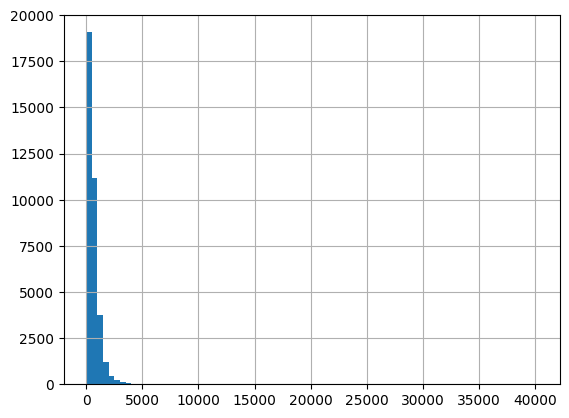

In [3]:
dataframe['description'].apply(len).hist(bins=80);

Отфильтруем слишком длинные описания

In [4]:
description_lens = dataframe['description'].apply(len)
dataframe = dataframe[description_lens < description_lens.quantile(0.99)]

Отфильтруем сэмплы без жанров, дублированные или с количеством слов в описании <= 5

In [5]:
df_filter = (
    dataframe['genres'].apply(lambda x: len(x) > 0) &
    dataframe['description'].apply(lambda x: len(x.split()) > 5) &
    ~dataframe['description'].duplicated(keep=False)
)
dataframe = dataframe[df_filter]
dataframe

,url,description,genres,tags,title,likes,rating,quality
1,https://tl.rulate.ru/book/121526,После Тайной комнаты два маловероятных союзник...,"[18+, гаремник, героическое фэнтези, драма, ко...","[18+, авторский мир, адаптация произведения, а...",Мы вместе,14,2.27 / 11 голосов,2 / 8 голосов
2,https://tl.rulate.ru/book/127105,Шестой год Гарри начинается с ужасного лета у ...,[фанфик],"[волшебники, гарри поттер, главный герой сильн...",Гарри Поттер и принц Слизерина,1,,
3,https://tl.rulate.ru/book/127071,Возрожденный в игровом мире злодей-пушечное мя...,"[боевик, боевые искусства, героическое фэнтези...","[алхимия, всемогущий главный герой, главный ге...",Охотник на демонов: Я стал богом в мире охоты ...,7,4.2 / 5 голосов,4.2 / 5 голосов
5,https://tl.rulate.ru/book/135844,В 2025 году судьба преподнесла Артуру Беннетту...,"[приключения, фанфик]","[выживание, злой главный герой, от слабого до ...",Наруто: Тропа войны,3,3 / 2 голоса,5 / 1 голос
6,https://tl.rulate.ru/book/134398,Возможное продолжение последней книги серии о ...,[фанфик],"[альбус дамблдор, воландеморт, волшебники, вол...",Будущее Гарри,1,,
...,...,...,...,...,...,...,...,...
36116,https://tl.rulate.ru/book/115301,\n\nТерриториальный менеджер\n\nК этому време...,[18+],"[18+, супружеская измена]",Территориальный менеджер | Терапевт,5,4.33 / 3 голоса,4.33 / 3 голоса
36117,https://tl.rulate.ru/book/115270,"Люк, почему ты не хочешь связать себя обязате...","[18+, мелодрама, приключения, романтика]","[18+, 21+]",Почему ты не берешь на себя обязательства? | Н...,11,4.2 / 5 голосов,4 / 5 голосов
36118,https://tl.rulate.ru/book/115765,Гг переселяется в мир Наруто в теле гражданско...,"[боевые искусства, приключения, фанфик, фэнтези]","[красивые женщины, от слабого до сильного, пер...",Наруто: Возрождение с Гура Гура но Ми,5,3 / 3 голоса,4.5 / 2 голоса
36119,https://tl.rulate.ru/book/39235,"После того как катастрофа обрушилась на Землю,...","[боевик, драма, комедия, научная фантастика, п...","[военные, война, главный герой мужчина, жесток...",Девятый специальный район,17,5 / 13 голосов,5 / 13 голосов


Подсчитаем количество появлений каждого жанра

In [6]:
from collections import Counter

genres_counts = Counter()

for genres in dataframe['genres']:
    genres_counts.update(genres)
genres_counts

Counter({'приключения': 16877,
         'фэнтези': 15692,
         'романтика': 13621,
         'боевик': 10286,
         'фанфик': 8438,
         'комедия': 7888,
         'боевые искусства': 7809,
         'фантастика': 7574,
         'гаремник': 7019,
         'повседневность': 6961,
         'драма': 5848,
         '18+': 5266,
         'сверхъестественное': 5138,
         'этти': 4611,
         'героическое фэнтези': 3634,
         'мистика': 3566,
         'психология': 3215,
         'школа': 3003,
         'научная фантастика': 2728,
         'история': 2338,
         'сёнэн': 1693,
         'дзёсэй': 1222,
         'трагедия': 1201,
         'сянься (XianXia)': 1026,
         'сёдзё': 970,
         'литрпг': 955,
         'мелодрама': 869,
         'смат': 867,
         'постапокалиптика': 846,
         'ужасы': 781,
         'уся (wuxia)': 779,
         'детектив': 750,
         'триллер': 730,
         'сюаньхуа': 675,
         'городское фэнтези': 654,
         'сэйнэн': 57

В жанрах кодомо, махо-сёдзе и додзинси крайне малое количество примеров + сгенерировать что-то четко к ним относящееся сложно - выбрасываем

In [7]:
def drop_genres(sample_list: list[str], columns_to_drop: list[str]) -> list:
    remain_list = [item for item in sample_list if item not in columns_to_drop]
    if 'сюаньхуань' in sample_list and 'сюаньхуа' not in sample_list:
        remain_list = [item for item in remain_list if item != 'сюаньхуань']
        remain_list.append('сюаньхуа')
    elif 'сюаньхуань' in sample_list:
        remain_list = [item for item in remain_list if item != 'сюаньхуань']
    return remain_list

columns_to_drop = ['кодомо', 'махо-сёдзё', 'додзинси']
dataframe['genres'] = dataframe['genres'].apply(lambda x: drop_genres(x, columns_to_drop))
dataframe = dataframe[dataframe['genres'].apply(len) > 0].reset_index(drop=True)

Бинаризуем лейблы, чтобы сделать стратифицировано val и test

In [8]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer

binarizer = MultiLabelBinarizer()
y = binarizer.fit_transform(dataframe['genres'])
X = dataframe

splitter1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter1.split(X, y))

X_trainval, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_trainval, y_val = y[train_idx], y[val_idx]

splitter2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train2_idx, test_idx = next(splitter2.split(X_trainval, y_trainval))

X_train, X_test = X_trainval.iloc[train2_idx], X_trainval.iloc[test_idx]
y_train, y_test = y_trainval[train2_idx], y_trainval[test_idx]

id2label = {num: label for num, label in enumerate(binarizer.classes_)}
label2id = {value: key for key, value in id2label.items()}

id2label

{0: '18+',
 1: '21+',
 2: 'арт',
 3: 'боевик',
 4: 'боевые искусства',
 5: 'гаремник',
 6: 'героическое фэнтези',
 7: 'городское фэнтези',
 8: 'детектив',
 9: 'дзёсэй',
 10: 'драма',
 11: 'история',
 12: 'киберпанк',
 13: 'комедия',
 14: 'литрпг',
 15: 'мелодрама',
 16: 'меха',
 17: 'мистика',
 18: 'научная фантастика',
 19: 'повседневность',
 20: 'постапокалиптика',
 21: 'приключения',
 22: 'психология',
 23: 'романтика',
 24: 'самурайский боевик',
 25: 'сверхъестественное',
 26: 'смат',
 27: 'спорт',
 28: 'сэйнэн',
 29: 'сюаньхуа',
 30: 'сянься (XianXia)',
 31: 'сёдзё',
 32: 'сёнэн',
 33: 'трагедия',
 34: 'триллер',
 35: 'ужасы',
 36: 'уся (wuxia)',
 37: 'фантастика',
 38: 'фанфик',
 39: 'фэнтези',
 40: 'школа',
 41: 'этти'}

In [9]:
import numpy as np
from transformers import PreTrainedTokenizer, AutoTokenizer
from datasets import Dataset
from typing import Any

def map_sample(sample: dict[str, Any], tokenizer: PreTrainedTokenizer, binarizer: MultiLabelBinarizer) -> dict[str, Any]:
    tokenized_sample = tokenizer(
        sample['description'],
        truncation=True,
        max_length=512)

    label_vector = np.zeros(len(binarizer.classes_), dtype=int)
    for genre in sample["genres"]:
        if genre in binarizer.classes_:
            label_vector[binarizer.classes_.tolist().index(genre)] = 1

    tokenized_sample["labels"] = label_vector.tolist()
    return tokenized_sample

model_name = 'deepvk/deberta-v1-base'

train_dataset = Dataset.from_pandas(X_train[['description', 'genres']])
val_dataset = Dataset.from_pandas(X_val[['description', 'genres']])
test_dataset = Dataset.from_pandas(X_test[['description', 'genres']])


tokenizer = AutoTokenizer.from_pretrained(model_name, token=os.environ['HUGGINGFACE_HUB_TOKEN'])

train_dataset = train_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))
val_dataset = val_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))
test_dataset = test_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))
test_dataset

Map:   0%|          | 0/23034 [00:00<?, ? examples/s]

Map:   0%|          | 0/6364 [00:00<?, ? examples/s]

Map:   0%|          | 0/2605 [00:00<?, ? examples/s]

Dataset({
    features: ['description', 'genres', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2605
})

Т.к. в классах наблюдается сильный дисбаланс, для обучения модели будет использоваться Focal Loss с $\gamma$ = 2

In [10]:
from transformers import AutoModelForSequenceClassification
import torch.nn as nn

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=y_test.shape[1],
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification",
    token=os.environ['HUGGINGFACE_HUB_TOKEN'])

model.dropout = nn.Identity()
model.pooler.dropout = nn.Dropout(0.3)

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at deepvk/deberta-v1-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
model

DebertaForSequenceClassification(
  (deberta): DebertaModel(
    (embeddings): DebertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): DebertaLayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaLayer(
          (attention): DebertaAttention(
            (self): DisentangledSelfAttention(
              (in_proj): Linear(in_features=768, out_features=2304, bias=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): DebertaLayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (intermediate): DebertaIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

In [ ]:
import torch

class_frequency = y_train.mean(axis=0)
pos_weight = torch.tensor((1 - class_frequency) / (class_frequency + 1e-9), dtype=torch.float)
pos_weight = pos_weight.clamp(max=10)

In [13]:
import torch.nn.functional as F
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding, EvalPrediction
from sklearn.metrics import f1_score, jaccard_score, hamming_loss

def compute_loss_func(outputs, labels, **_):
    return F.binary_cross_entropy_with_logits(outputs.logits, labels.float(), pos_weight=pos_weight.to(outputs.logits.device))

def compute_metrics(eval_pred: EvalPrediction) -> dict:
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "jaccard": jaccard_score(labels, preds, average="samples", zero_division=0),
        "hamming": hamming_loss(labels, preds),
    }

collate_fn = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir='./result_model',
    eval_strategy='epoch',
    do_train=True,
    do_eval=True,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=16,
    per_device_eval_batch_size=16,
    lr_scheduler_type="cosine",
    warmup_ratio=0.0,
    save_total_limit=1,
    num_train_epochs=7
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    eval_dataset=val_dataset,
    compute_loss_func=compute_loss_func,
    compute_metrics=compute_metrics
)

In [14]:
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1,Jaccard,Hamming
1,No log,0.717050,0.247393,0.286253,0.196705
2,No log,0.670995,0.310201,0.309324,0.184973
3,11.418700,0.653232,0.331177,0.341548,0.159510
4,11.418700,0.641079,0.340621,0.344259,0.156909
5,11.418700,0.635149,0.344361,0.343830,0.162488
6,9.722800,0.633908,0.349265,0.342585,0.162102
7,9.722800,0.636335,0.348424,0.347167,0.156513


TrainOutput(global_step=1260, training_loss=10.308249821738592, metrics={'train_runtime': 4889.5231, 'train_samples_per_second': 32.976, 'train_steps_per_second': 0.258, 'total_flos': 4.243417158577766e+16, 'train_loss': 10.308249821738592, 'epoch': 7.0})

In [18]:
from sklearn.metrics import precision_recall_curve
from numpy.typing import NDArray

def fit_threshold(logits: NDArray, y: NDArray):
    prob = 1/(1+np.exp(-logits))
    threshold_array = np.zeros(prob.shape[1])

    for class_ in range(prob.shape[1]):
        precision, recall,threshold = precision_recall_curve(y[:,class_], prob[:,class_])
        f1 = 2 * precision * recall/(precision + recall + 1e-9)
        threshold_array[class_] = threshold[np.nanargmax(f1)]
    return threshold_array

val_logits = np.concatenate([trainer.predict(val_dataset).predictions], axis=0)
threshold = fit_threshold(val_logits, y_val)

def compute_metrics(eval_pred):
    logits = eval_pred.predictions[0] if isinstance(eval_pred.predictions, tuple) else eval_pred.predictions
    probs = 1/(1+np.exp(-logits))
    preds = (probs >= threshold).astype(int)
    labels = eval_pred.label_ids
    return {
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "jaccard": jaccard_score(labels, preds, average="samples", zero_division=0),
        "hamming": hamming_loss(labels, preds),
    }



In [22]:
from sklearn.metrics import classification_report

probs_val = 1/(1+np.exp(-val_logits))
preds_val = (probs_val >= threshold).astype(int)

print("val macro_f1:", f1_score(y_val, preds_val, average="macro", zero_division=0))
print("val jaccard:", jaccard_score(y_val, preds_val, average="samples", zero_division=0))
print("val hamming:", hamming_loss(y_val, preds_val))
print(classification_report(y_val, preds_val, target_names=binarizer.classes_))

val macro_f1: 0.3874704320266914
val jaccard: 0.37388393917324186
val hamming: 0.1432686839663584
                     precision    recall  f1-score   support

                18+       0.62      0.71      0.66      1053
                21+       0.42      0.65      0.51        88
                арт       0.33      0.13      0.18        79
             боевик       0.52      0.86      0.65      2057
   боевые искусства       0.52      0.67      0.59      1562
           гаремник       0.43      0.58      0.49      1404
героическое фэнтези       0.28      0.46      0.34       727
  городское фэнтези       0.08      0.23      0.12       131
           детектив       0.20      0.16      0.18       150
             дзёсэй       0.32      0.64      0.43       244
              драма       0.39      0.62      0.48      1170
            история       0.23      0.29      0.26       468
          киберпанк       0.08      0.21      0.12        38
            комедия       0.34      0.75      0

In [21]:
test_preds = trainer.predict(test_dataset)
test_logits = test_preds.predictions
probs_test = 1/(1+np.exp(-test_logits))
preds_test = (probs_test >= threshold).astype(int)

print("test macro_f1:", f1_score(y_test, preds_test, average="macro", zero_division=0))
print("test jaccard:", jaccard_score(y_test, preds_test, average="samples", zero_division=0))
print("test hamming:", hamming_loss(y_test, preds_test))
print(classification_report(y_test, preds_test, target_names=binarizer.classes_))


test macro_f1: 0.3769833315559015
test jaccard: 0.36796105425197495
test hamming: 0.1438442555525089
                     precision    recall  f1-score   support

                18+       0.61      0.73      0.67       421
                21+       0.46      0.51      0.49        35
                арт       0.25      0.06      0.10        32
             боевик       0.52      0.86      0.64       823
   боевые искусства       0.52      0.69      0.59       625
           гаремник       0.41      0.55      0.47       562
героическое фэнтези       0.29      0.46      0.36       291
  городское фэнтези       0.13      0.35      0.19        52
           детектив       0.27      0.23      0.25        60
             дзёсэй       0.32      0.70      0.44        98
              драма       0.36      0.57      0.44       468
            история       0.26      0.33      0.29       187
          киберпанк       0.00      0.00      0.00        15
            комедия       0.34      0.77    

In [23]:
save_dir = "./output/"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

train_dataset.save_to_disk("./datasets/train")
val_dataset.save_to_disk("./datasets/val")
test_dataset.save_to_disk("./datasets/test")

Saving the dataset (0/1 shards):   0%|          | 0/23034 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6364 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2605 [00:00<?, ? examples/s]